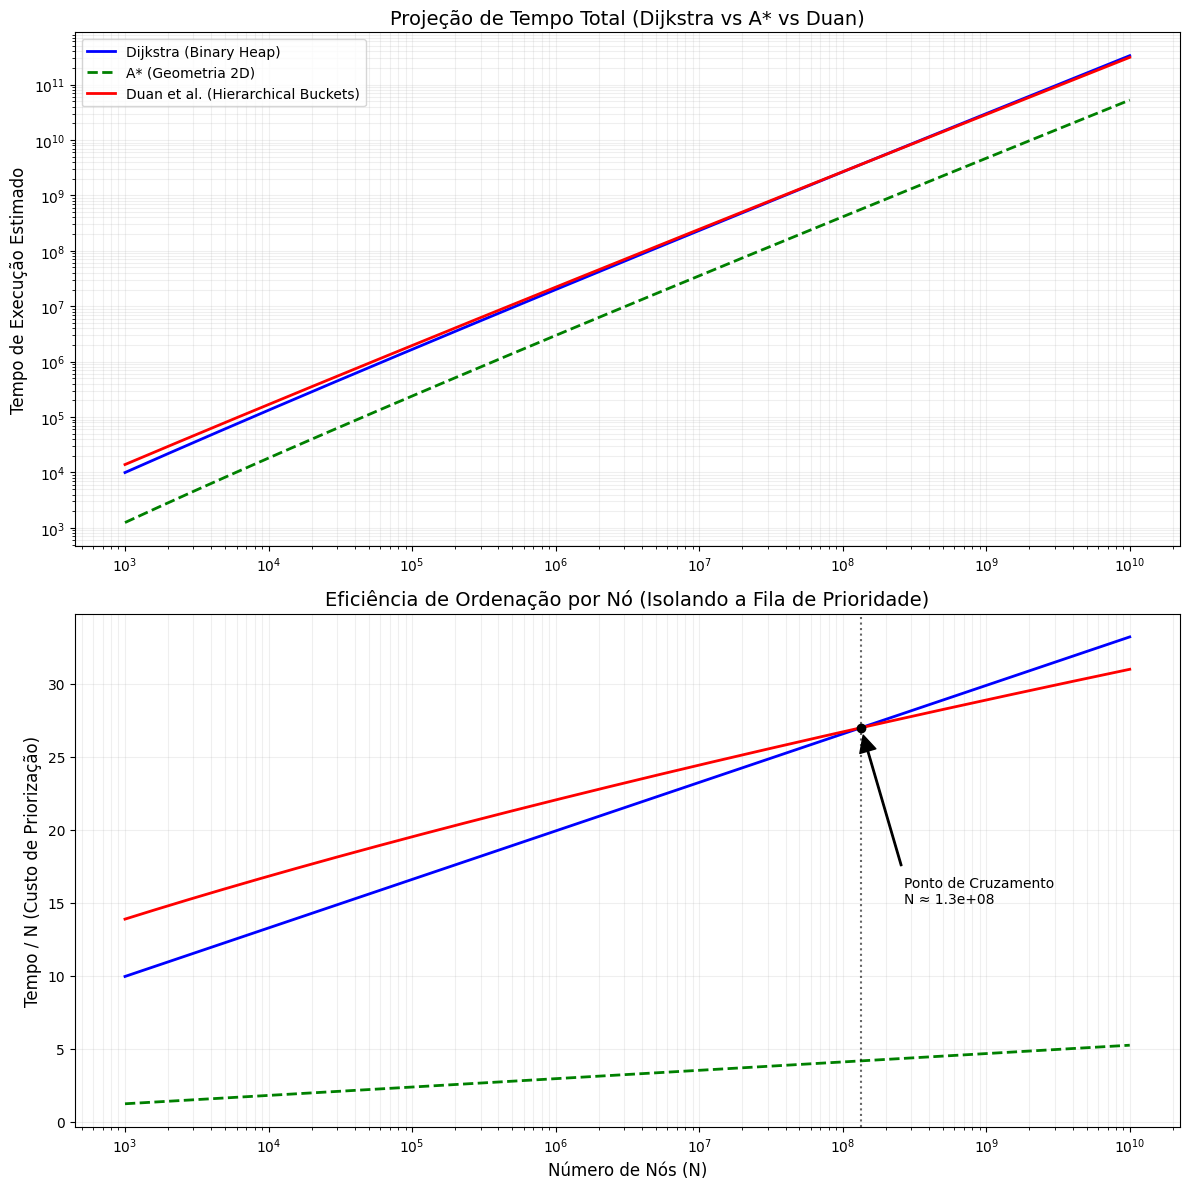

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_algorithm_performance_v3():
    # Faixa de número de nós (n) - estendida para ver o crossover
    # De 10^3 até 10^10
    n = np.geomspace(1e3, 1e10, 300)
    
    # --- MODELAGEM DAS COMPLEXIDADES ---
    
    # 1. DIJKSTRA: O(n log n)
    # c1 = 1.0 (Referência de eficiência)
    c_dijkstra = 1.0
    y_dijkstra = c_dijkstra * n * np.log2(n)
    
    # 2. A ESTRELA (A*): O(n log n) com exploração reduzida
    # Alpha representa a percentagem do grafo visitada (ex: 15%)
    alpha = 0.15
    c_astar = 1.15 # Custo ligeiramente superior por nó devido à heurística
    y_astar = c_astar * (alpha * n) * np.log2(alpha * n)
    
    # 3. DUAN ET AL. (2025): O(n log^(2/3) n)
    # Ajustamos a constante para que o cruzamento ocorra em N aproximado de 10^8
    # A constante reflete o custo de gerir baldes hierárquicos recursivos.
    c_duan = 3.0 
    y_duan = c_duan * n * (np.log2(n) ** (2/3))

    # --- CÁLCULO DO PONTO DE CRUZAMENTO (TEÓRICO) ---
    # log2(n) = c_duan * log2(n)^(2/3) => log2(n)^(1/3) = c_duan
    # log2(n) = c_duan^3 => n = 2^(c_duan^3)
    crossover_n = 2**(c_duan**3)

    # --- VISUALIZAÇÃO ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # GRÁFICO 1: Tempo Total (Log-Log)
    ax1.plot(n, y_dijkstra, label='Dijkstra (Binary Heap)', color='blue', linewidth=2)
    ax1.plot(n, y_astar, label='A* (Geometria 2D)', color='green', linestyle='--', linewidth=2)
    ax1.plot(n, y_duan, label='Duan et al. (Hierarchical Buckets)', color='red', linewidth=2)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_title('Projeção de Tempo Total (Dijkstra vs A* vs Duan)', fontsize=14)
    ax1.set_ylabel('Tempo de Execução Estimado', fontsize=12)
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.legend()

    # GRÁFICO 2: Custo por Nó (Tempo / N) - Onde a interseção é visível
    # Aqui removemos o fator linear N para ver apenas o crescimento da ordenação
    ax2.plot(n, y_dijkstra/n, color='blue', linewidth=2, label='Custo log(n)')
    ax2.plot(n, y_astar/n, color='green', linestyle='--', linewidth=2, label='Custo A* (Poda)')
    ax2.plot(n, y_duan/n, color='red', linewidth=2, label='Custo log^(2/3)(n)')
    
    ax2.set_xscale('log')
    ax2.set_title('Eficiência de Ordenação por Nó (Isolando a Fila de Prioridade)', fontsize=14)
    ax2.set_xlabel('Número de Nós (N)', fontsize=12)
    ax2.set_ylabel('Tempo / N (Custo de Priorização)', fontsize=12)
    ax2.grid(True, which="both", ls="-", alpha=0.2)
    
    # Marcação do cruzamento Duan vs Dijkstra
    if crossover_n < 1e10:
        ax2.axvline(x=crossover_n, color='black', linestyle=':', alpha=0.6)
        ax2.scatter([crossover_n], [c_duan * (np.log2(crossover_n)**(2/3))], color='black', zorder=5)
        ax2.annotate(f'Ponto de Cruzamento\nN ≈ {crossover_n:.1e}', 
                     xy=(crossover_n, c_duan * (np.log2(crossover_n)**(2/3))), 
                     xytext=(crossover_n*2, 15),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_algorithm_performance_v3()